In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mplt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("M:/DataScience/ds_venv/Predict insurance charges/insurance.csv")

In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

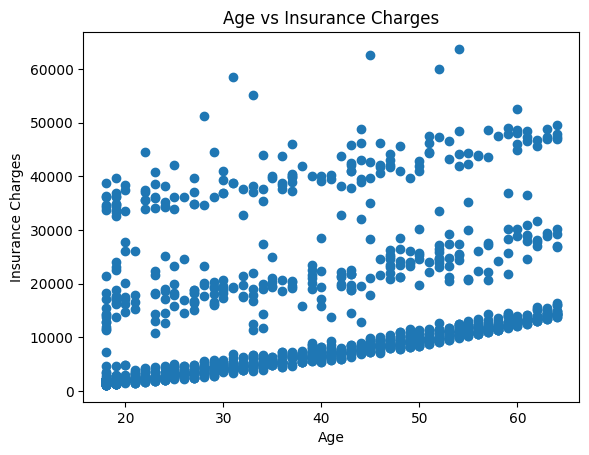

In [11]:
mplt.scatter(df["age"], df["charges"])
mplt.xlabel("Age")
mplt.ylabel("Insurance Charges")
mplt.title("Age vs Insurance Charges")
mplt.show()

In [12]:
X = df[["age"]]
y = df["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (936, 1)
Testing data size: (402, 1)


In [13]:
intercept = model.intercept_
slope = model.coef_[0]
print("Intercept (bo):", intercept)
print("Slope (b1):", slope)

Intercept (bo): 3673.8368753317463
Slope (b1): 247.5995509234235


In [14]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Age": X_test["age"], "Actual Charges": y_test, "Predicted Charges": y_pred})
comparison

,Age,Actual Charges,Predicted Charges
764,45,9095.06825,14815.816667
887,36,5272.17580,12587.420709
890,64,29330.98315,19520.208134
1293,46,9301.89355,15063.416218
259,19,33750.29180,8378.228343
...,...,...,...
701,50,9541.69555,16053.814422
672,36,4399.73100,12587.420709
1163,18,2200.83085,8130.628792
1103,58,11363.28320,18034.610829


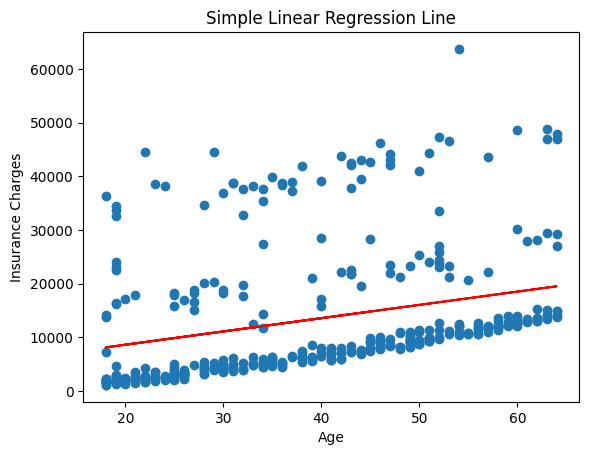

In [15]:
mplt.scatter(X_test, y_test)
mplt.plot(X_test, y_pred, color='red')
mplt.xlabel("Age")
mplt.ylabel("Insurance Charges")
mplt.title("Simple Linear Regression Line")
mplt.show()

In [16]:
new_age_df = pd.DataFrame({'age': [35]})
predicted_charges = model.predict(new_age_df)
print("Predicted Charges for age 35:", predicted_charges[0])

Predicted Charges for age 35: 12339.821157651568
